# Spark 03: Machine Learning a Escala con Spark MLlib
**Universidad del Valle de Guatemala — Data Science**

En esta práctica construiremos y evaluaremos un pipeline de **Machine Learning distribuido** para predecir los puntos anotados (`PTS`) por un jugador de la NBA a partir de estadísticas de rendimiento en cancha. Aprenderemos a prevenir la fuga de información (*Data Leakage*), realizar muestreo seguro para análisis exploratorio, vectorizar variables con `VectorAssembler`, entrenar modelos de regresión lineal y evaluar diagnósticos de residuos a escala.

### 1. Verificación del Entorno de Ejecución
Comprobamos la compatibilidad de Java 17 y la versión de PySpark activa en el contenedor Docker.

In [1]:
import os
import pyspark


print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("PySpark:", pyspark.__version__)

JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64
PySpark: 3.5.1


### 2. Inicialización de la sesión de spark
Inicializamos la sesión de Spark configurando el motor en modo local con todos los hilos del CPU.

In [20]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NotebookPySpark")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Java:", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))

Spark: 3.5.1
Java: 17.0.20.1


### 3. Definición de la Carpeta de Trabajo
Establecemos la ruta hacia los datos de la NBA montados en `/opt/app/working_dir/`.

In [4]:
mydir = "/opt/app/working_dir/"

### 4. Carga del Dataset de la NBA (`games_details.csv`)
Cargamos las estadísticas individuales por partido con inferencia de esquema y encabezado activados.

In [21]:
nba = spark.read.csv( 
  header = True, 
  inferSchema = True, 
  path = mydir + 'nba/games_details.csv' 
) 
nba.printSchema()

root
 |-- GAME_ID: integer (nullable = true)
 |-- TEAM_ID: integer (nullable = true)
 |-- TEAM_ABBREVIATION: string (nullable = true)
 |-- TEAM_CITY: string (nullable = true)
 |-- PLAYER_ID: integer (nullable = true)
 |-- PLAYER_NAME: string (nullable = true)
 |-- START_POSITION: string (nullable = true)
 |-- COMMENT: string (nullable = true)
 |-- MIN: string (nullable = true)
 |-- FGM: double (nullable = true)
 |-- FGA: double (nullable = true)
 |-- FG_PCT: double (nullable = true)
 |-- FG3M: double (nullable = true)
 |-- FG3A: double (nullable = true)
 |-- FG3_PCT: double (nullable = true)
 |-- FTM: double (nullable = true)
 |-- FTA: double (nullable = true)
 |-- FT_PCT: double (nullable = true)
 |-- OREB: double (nullable = true)
 |-- DREB: double (nullable = true)
 |-- REB: double (nullable = true)
 |-- AST: double (nullable = true)
 |-- STL: double (nullable = true)
 |-- BLK: double (nullable = true)
 |-- TO: double (nullable = true)
 |-- PF: double (nullable = true)
 |-- PTS: dou

In [6]:
nba.show(5)

26/09/21 16:21:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+--------+----------+-----------------+----------+---------+-----------------+--------------+-------+-----+----+----+------+----+----+-------+---+----+------+----+----+---+----+---+---+---+---+----+----------+
| GAME_ID|   TEAM_ID|TEAM_ABBREVIATION| TEAM_CITY|PLAYER_ID|      PLAYER_NAME|START_POSITION|COMMENT|  MIN| FGM| FGA|FG_PCT|FG3M|FG3A|FG3_PCT|FTM| FTA|FT_PCT|OREB|DREB|REB| AST|STL|BLK| TO| PF| PTS|PLUS_MINUS|
+--------+----------+-----------------+----------+---------+-----------------+--------------+-------+-----+----+----+------+----+----+-------+---+----+------+----+----+---+----+---+---+---+---+----+----------+
|42000102|1610612764|              WAS|Washington|   203078|     Bradley Beal|             F|   NULL|34:36|14.0|28.0|   0.5| 1.0| 6.0|  0.167|4.0| 6.0| 0.667| 0.0| 4.0|4.0| 3.0|1.0|0.0|1.0|0.0|33.0|     -22.0|
|42000102|1610612764|              WAS|Washington|  1629060|    Rui Hachimura|             F|   NULL|25:50| 4.0| 6.0| 0.667| 1.0| 1.0|    1.0|2.0| 3.0| 0.667| 2

### 5. Selección de Variables Predictoras y Prevención de Data Leakage
Definimos las variables independientes (`feature_columns`) y la variable objetivo (`label_column = 'PTS'`).

**NO** incluimos `FGM` (tiros convertidos), `FG3M` (triples convertidos) ni `FTM` (tiros libres convertidos) porque los puntos totales son una combinación lineal exacta de ellos ($PTS = 2 \times FGM + FG3M + FTM$). Incluirlos provocaría **Fuga de datos o Data Leakage** directo, haciendo que el modelo aprenda una fórmula contable trivial en lugar de estimar la capacidad anotadora a partir del volumen de juego.

In [7]:
from pyspark.sql import functions as f

# Variables que utilizaremos para estimar los puntos del jugador
feature_columns = [
    "minutes",
    "FGA",   # Tiros de campo intentados
    "FG3A",  # Triples intentados
    "FTA",   # Tiros libres intentados
    "OREB",  # Rebotes ofensivos
    "DREB",  # Rebotes defensivos
    "AST",   # Asistencias
    "STL",   # Robos
    "BLK",   # Bloqueos
    "TO",    # Pérdidas de balón
    "PF"     # Faltas personales
]

# Variable que queremos estimar
label_column = "PTS"

### 6. Feature Extraction: Extracción de Minutos Jugados con una expresión regular
La columna `MIN` viene en formato texto como `"32:15"` o `"08:42"`. Spark ML requiere variables numéricas continuas.
* Utilizamos `f.regexp_extract(f.col("MIN"), r"^(\d+)", 1)` para capturar los dígitos antes de los dos puntos y los convertimos a `double` creando la nueva columna `minutes`.

In [8]:
nba_ml = nba.withColumn(
    "minutes",
    f.regexp_extract(f.col("MIN"), r"^(\d+)", 1).cast("double")
)
nba_ml.select("PLAYER_NAME", "MIN", "minutes").show(10)

+------------------+-----+-------+
|       PLAYER_NAME|  MIN|minutes|
+------------------+-----+-------+
|      Bradley Beal|34:36|   34.0|
|     Rui Hachimura|25:50|   25.0|
|          Alex Len|12:11|   12.0|
|         Raul Neto|19:19|   19.0|
| Russell Westbrook|29:07|   29.0|
|     Davis Bertans|23:43|   23.0|
|         Ish Smith|23:20|   23.0|
|    Daniel Gafford|20:00|   20.0|
|Chandler Hutchison|16:29|   16.0|
|       Robin Lopez|10:15|   10.0|
+------------------+-----+-------+
only showing top 10 rows



### 7. Filtrado de Columnas Relevantes
Reducimos el DataFrame quedándonos únicamente con el nombre del jugador, las variables predictoras y la variable objetivo.

In [9]:
nba_ml = nba_ml.select(
    "PLAYER_NAME",
    *feature_columns,
    label_column
)
nba_ml.show(10)

+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|       PLAYER_NAME|minutes| FGA|FG3A| FTA|OREB|DREB| AST|STL|BLK| TO| PF| PTS|
+------------------+-------+----+----+----+----+----+----+---+---+---+---+----+
|      Bradley Beal|   34.0|28.0| 6.0| 6.0| 0.0| 4.0| 3.0|1.0|0.0|1.0|0.0|33.0|
|     Rui Hachimura|   25.0| 6.0| 1.0| 3.0| 2.0| 5.0| 1.0|0.0|0.0|3.0|4.0|11.0|
|          Alex Len|   12.0| 5.0| 0.0| 0.0| 3.0| 2.0| 0.0|1.0|0.0|0.0|2.0| 6.0|
|         Raul Neto|   19.0| 5.0| 2.0| 0.0| 1.0| 2.0| 1.0|0.0|0.0|0.0|2.0| 4.0|
| Russell Westbrook|   29.0|10.0| 3.0|10.0| 2.0| 4.0|11.0|0.0|0.0|4.0|0.0|10.0|
|     Davis Bertans|   23.0| 4.0| 4.0| 0.0| 0.0| 2.0| 0.0|0.0|0.0|0.0|6.0| 0.0|
|         Ish Smith|   23.0|14.0| 2.0| 0.0| 0.0| 1.0| 3.0|0.0|0.0|1.0|1.0|10.0|
|    Daniel Gafford|   20.0| 4.0| 0.0| 9.0| 4.0| 2.0| 1.0|1.0|1.0|1.0|1.0|11.0|
|Chandler Hutchison|   16.0| 4.0| 0.0| 2.0| 0.0| 2.0| 1.0|0.0|0.0|1.0|1.0| 4.0|
|       Robin Lopez|   10.0| 3.0| 0.0| 0

### 8. Limpieza de Registros Incompletos y Jugadores sin Minutos
En la NBA, muchos jugadores son convocados al banquillo pero no ingresan a la cancha (DNP: Did Not Play). Sus registros contienen valores nulos o 0 minutos.
* `.dropna(subset=...)`: Elimina cualquier fila con valores nulos en las columnas del modelo.
* `.filter(f.col("minutes") > 0)`: Filtra exclusivamente jugadores que hayan disputado al menos 1 minuto de juego.

In [10]:
print("Filas antes de eliminar nulos:", nba_ml.count())
nba_ml = nba_ml.dropna(subset=feature_columns + [label_column])
print("Filas tras eliminar nulos:", nba_ml.count())

print("Jugadores con minutos <= 0:", nba_ml.filter(f.col("minutes") <= 0).count())
nba_ml = nba_ml.filter(f.col("minutes") > 0)
print("Filas finales limpias:", nba_ml.count())

Filas antes de eliminar nulos: 615626
Filas tras eliminar nulos: 515565
Jugadores con minutos <= 0: 5373
Filas finales limpias: 510192


### 9. Resumen Estadístico Descriptivo en Spark
Calculamos conteos, medias, desviaciones estándar, mínimos y máximos sobre todo el clúster con `.summary().show(vertical=True)`.

In [11]:
nba_ml.select(
    *feature_columns,
    label_column
).summary().show(vertical=True)

[Stage 19:>                                                         (0 + 1) / 1]

-RECORD 0----------------------
 summary | count               
 minutes | 510192              
 FGA     | 510192              
 FG3A    | 510192              
 FTA     | 510192              
 OREB    | 510192              
 DREB    | 510192              
 AST     | 510192              
 STL     | 510192              
 BLK     | 510192              
 TO      | 510192              
 PF      | 510192              
 PTS     | 510192              
-RECORD 1----------------------
 summary | mean                
 minutes | 22.734105983629693  
 FGA     | 7.961432166713708   
 FG3A    | 2.120358610091887   
 FTA     | 2.3266691755260767  
 OREB    | 1.0409316492614544  
 DREB    | 3.057276476306959   
 AST     | 2.113073117571424   
 STL     | 0.7306719823125412  
 BLK     | 0.46707318029290934 
 TO      | 1.3405580644149653  
 PF      | 2.0320781196098725  
 PTS     | 9.744353106281556   
-RECORD 2----------------------
 summary | stddev              
 minutes | 11.072455681177136  
 FGA    

### 10. Muestreo Estratificado y Visualización Local
Para visualizar con Seaborn/Matplotlib, **NUNCA** debemos convertir un DataFrame distribuido masivo completo con `.toPandas()`, ya que saturaría la RAM del Driver provocando un `OutOfMemoryError`.
* En su lugar, tomamos una muestra representativa con `.sample(fraction=0.10, seed=42).limit(10000).toPandas()`.

In [12]:
nba_sample = (
    nba_ml
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .limit(10000)
    .toPandas()
)

print("Filas utilizadas en la muestra local:", len(nba_sample))

Filas utilizadas en la muestra local: 10000


#### 10.1. Distribución de Puntos Anotados
Observamos la asimetría positiva en la anotación: la mayoría de jugadores anota entre 0 y 15 puntos por partido.

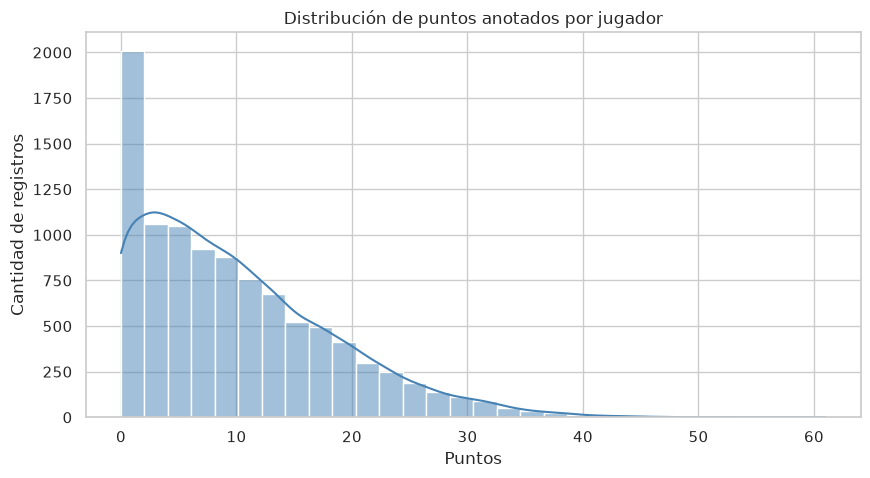

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.histplot(data=nba_sample, x="PTS", bins=30, kde=True, color="steelblue")
plt.title("Distribución de puntos anotados por jugador")
plt.xlabel("Puntos")
plt.ylabel("Cantidad de registros")
plt.show()

#### 10.2. Relación entre Minutos Jugados y Puntos
Existe una fuerte correlación positiva entre minutos y puntos, pero con alta dispersión (varianza creciente).

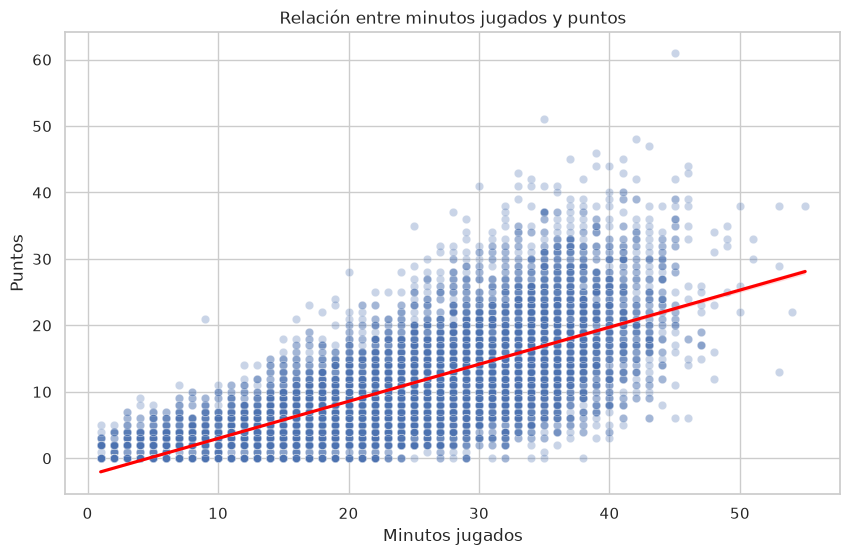

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=nba_sample, x="minutes", y="PTS", alpha=0.30)
sns.regplot(data=nba_sample, x="minutes", y="PTS", scatter=False, color="red")
plt.title("Relación entre minutos jugados y puntos")
plt.xlabel("Minutos jugados")
plt.ylabel("Puntos")
plt.show()

#### 10.3. Matriz de Correlación de Características
Observamos que `FGA` (tiros intentados) y `FTA` (tiros libres intentados) muestran la correlación lineal más alta con `PTS`.

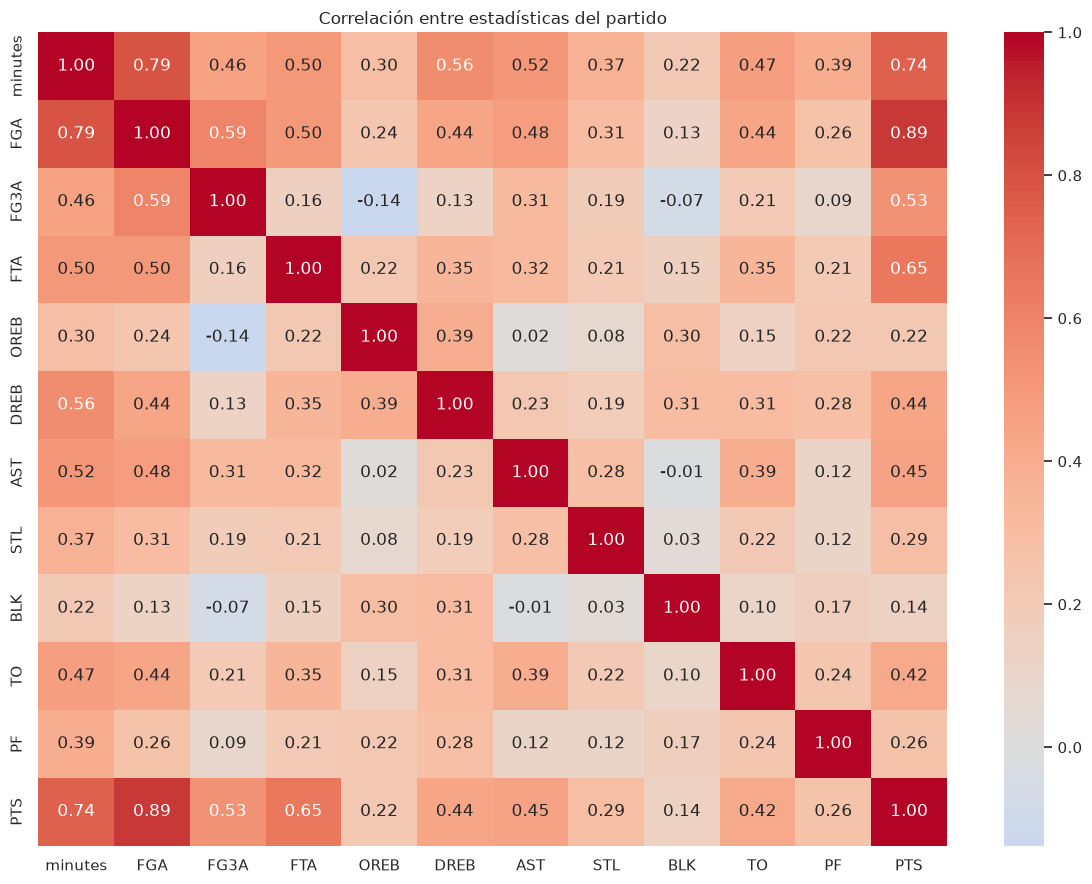

In [16]:
correlation_columns = feature_columns + [label_column]
correlation_matrix = nba_sample[correlation_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlación entre estadísticas del partido")
plt.tight_layout()
plt.show()

### 11. Vectorización con `VectorAssembler` (Spark ML)
A diferencia de bibliotecas locales donde se ingresan matrices NumPy, Spark ML requiere que todas las variables predictoras se empaqueten en una única columna de tipo `Vector` (ya sea `DenseVector` o `SparseVector`).
* `VectorAssembler(inputCols=..., outputCol="features")`: Transforma múltiples columnas numéricas en un vector estructurado para optimizar la serialización y el cómputo distribuido.

In [22]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

nba_vectorized = assembler.transform(nba_ml)
nba_vectorized.select("PLAYER_NAME", "features", "PTS").show(5, truncate=False)

+-----------------+-------------------------------------------------+----+
|PLAYER_NAME      |features                                         |PTS |
+-----------------+-------------------------------------------------+----+
|Bradley Beal     |[34.0,28.0,6.0,6.0,0.0,4.0,3.0,1.0,0.0,1.0,0.0]  |33.0|
|Rui Hachimura    |[25.0,6.0,1.0,3.0,2.0,5.0,1.0,0.0,0.0,3.0,4.0]   |11.0|
|Alex Len         |(11,[0,1,4,5,7,10],[12.0,5.0,3.0,2.0,1.0,2.0])   |6.0 |
|Raul Neto        |[19.0,5.0,2.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,2.0]   |4.0 |
|Russell Westbrook|[29.0,10.0,3.0,10.0,2.0,4.0,11.0,0.0,0.0,4.0,0.0]|10.0|
+-----------------+-------------------------------------------------+----+
only showing top 5 rows



### 12. División Train/Test Distribuida (`randomSplit`)
Separamos el DataFrame distribuido en un 70% para entrenamiento y un 30% para prueba con una semilla fijada (`seed=42`) para garantizar reproducibilidad.

In [23]:
train_data, test_data = nba_vectorized.randomSplit(
    weights=[0.70, 0.30],
    seed=42
)

print("Registros de entrenamiento:", train_data.count())
print("Registros de prueba:", test_data.count())

Registros de entrenamiento: 357328
Registros de prueba: 152864


### 13. Definición y Entrenamiento de Regresión Lineal (`LinearRegression`)
Instanciamos el estimador de Regresión Lineal de Spark ML y lo ajustamos sobre el conjunto de entrenamiento mediante `.fit(train_data)`.

In [24]:
from pyspark.ml.regression import LinearRegression

lr = LinearRegression(
    featuresCol="features",
    labelCol="PTS",
    predictionCol="prediction",
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

# Entrenamos:
lr_model = lr.fit(train_data)

Le pedimos a spark un modelo lineal sin regularización ninguna, por lo que nos advierte que si hay multicolinealidad puede sobreajustarse

### 14. Inspección de Coeficientes e Intercepto
Visualizamos el peso matemático que el modelo aprendió para cada característica en la predicción de puntos.

In [25]:
print("Intercepto:", lr_model.intercept)

for feature, coefficient in zip(feature_columns, lr_model.coefficients):
    print(f"{feature:10s}: {coefficient:.4f}")

Intercepto: -0.7340519450669345
minutes   : 0.0168
FGA       : 0.9626
FG3A      : 0.2183
FTA       : 0.8011
OREB      : -0.1049
DREB      : 0.0650
AST       : -0.0457
STL       : 0.0001
BLK       : 0.1137
TO        : 0.0020
PF        : 0.0288


### 15. Inferencia sobre el Conjunto de Prueba (`.transform()`)
Aplicamos el modelo entrenado sobre los datos no vistos (`test_data`) para generar la columna `prediction`.

In [26]:
predictions_lr = lr_model.transform(test_data)

predictions_lr.select(
    "PLAYER_NAME",
    f.col("PTS").alias("Puntos_reales"),
    f.round("prediction", 2).alias("Puntos_estimados")
).show(20, truncate=False)

+------------+-------------+----------------+
|PLAYER_NAME |Puntos_reales|Puntos_estimados|
+------------+-------------+----------------+
|Aaron Gordon|12.0         |8.86            |
|Aaron Gordon|6.0          |12.56           |
|Aaron Gordon|8.0          |7.33            |
|Aaron Gordon|2.0          |7.2             |
|Aaron Gordon|14.0         |13.31           |
|Aaron Gordon|12.0         |11.93           |
|Aaron Gordon|15.0         |12.13           |
|Aaron Gordon|6.0          |3.8             |
|Aaron Gordon|9.0          |8.81            |
|Aaron Gordon|16.0         |12.21           |
|Aaron Gordon|20.0         |16.04           |
|Aaron Gordon|24.0         |17.73           |
|Aaron Gordon|7.0          |8.05            |
|Aaron Gordon|13.0         |13.83           |
|Aaron Gordon|9.0          |12.59           |
|Aaron Gordon|16.0         |17.58           |
|Aaron Gordon|10.0         |8.57            |
|Aaron Gordon|15.0         |11.31           |
|Aaron Gordon|17.0         |15.65 

### 16. Evaluación del modelo (`RegressionEvaluator`)
Calculamos el Error Absoluto Medio (MAE), la Raíz del Error Cuadrático Medio (RMSE) y el Coeficiente de Determinación ($R^2$).

In [27]:
from pyspark.ml.evaluation import RegressionEvaluator

mae_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="mae")
mae = mae_evaluator.evaluate(predictions_lr)

rmse_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="rmse")
rmse = rmse_evaluator.evaluate(predictions_lr)

r2_evaluator = RegressionEvaluator(labelCol="PTS", predictionCol="prediction", metricName="r2")
r2 = r2_evaluator.evaluate(predictions_lr)

print("Evaluación de la regresión lineal base:")
print("----------------------------------------")
print(f"MAE : {mae:.4f} puntos")
print(f"RMSE: {rmse:.4f} puntos")
print(f"R²  : {r2:.4f}")

Evaluación de la regresión lineal base:
----------------------------------------
MAE : 2.4195 puntos
RMSE: 3.2189 puntos
R²  : 0.8390


### 17. Diagnóstico Visual: Puntos Reales vs. Predichos
Comparamos la predicción contra la línea diagonal ideal $y = x$.

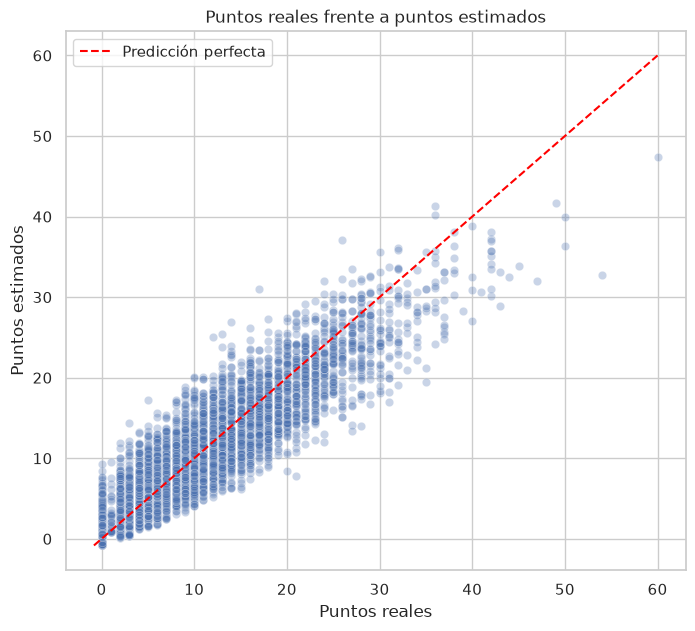

In [28]:
predictions_sample = (
    predictions_lr
    .select("PTS", "prediction")
    .limit(5000)
    .toPandas()
)

plt.figure(figsize=(8, 7))
sns.scatterplot(data=predictions_sample, x="PTS", y="prediction", alpha=0.30)
minimum = min(predictions_sample["PTS"].min(), predictions_sample["prediction"].min())
maximum = max(predictions_sample["PTS"].max(), predictions_sample["prediction"].max())
plt.plot([minimum, maximum], [minimum, maximum], color="red", linestyle="--", label="Predicción perfecta")
plt.title("Puntos reales frente a puntos estimados")
plt.xlabel("Puntos reales")
plt.ylabel("Puntos estimados")
plt.legend()
plt.show()

### 18. Análisis de Residuos ($e = y - \hat{y}$)
Calculamos los residuos para comprobar si cumplen con los supuestos de media cero y simetría, o si presentan heterocedasticidad.

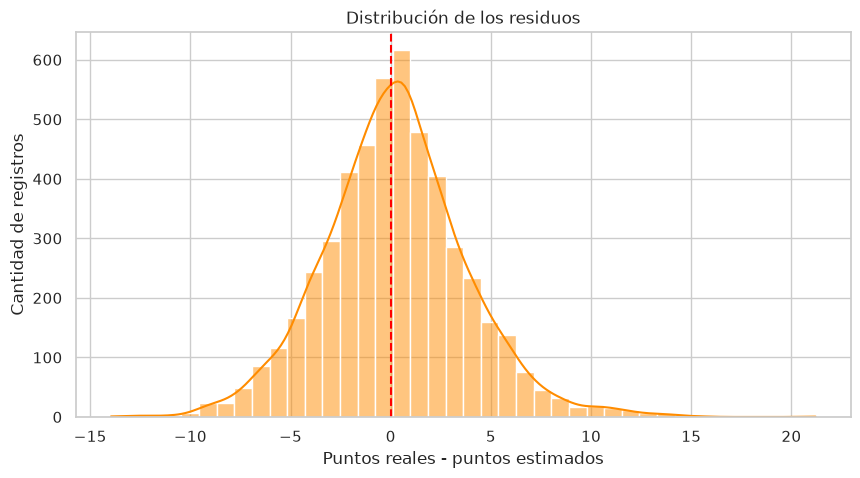

In [29]:
predictions_lr = predictions_lr.withColumn(
    "residual",
    f.col("PTS") - f.col("prediction")
)

residuals_sample = predictions_lr.select("residual").limit(5000).toPandas()

plt.figure(figsize=(10, 5))
sns.histplot(data=residuals_sample, x="residual", bins=40, kde=True, color="darkorange")
plt.axvline(x=0, color="red", linestyle="--")
plt.title("Distribución de los residuos")
plt.xlabel("Puntos reales - puntos estimados")
plt.ylabel("Cantidad de registros")
plt.show()

---
## EJERCICIO PRÁCTICO DE ASISTENCIA (Trabajo de Clase)
**Instrucciones:** Responde las siguientes preguntas analíticas y completa los retos propuestos a continuación. Asegúrate de ejecutar todas las celdas antes de entregar.

### Parte A: Análisis Crítico y Conceptual

#### 1. Prevención de Fuga de Información
En la celda de selección de variables se excluyeron `FGM` (tiros de campo encestados), `FG3M` (triples encestados) y `FTM` (tiros libres encestados).
- **Pregunta 1:** Si las hubiéramos incluido en el modelo, ¿qué habría ocurrido con el valor de $R^2$ y con la utilidad real del modelo para un equipo técnico durante un partido en vivo?

> **Respuesta 1:**
(Escribe tu respuesta aquí)

#### 2. Arquitectura Big Data: Driver vs. Executors
En la celda de visualización exploratoria se ejecutó:
```python
nba_sample = nba_ml.sample(withReplacement=False, fraction=0.10, seed=42).limit(10000).toPandas()
```
- **Pregunta 2.1:** ¿Por qué es una mala práctica en entornos de producción ejecutar `df.toPandas()` directamente sobre un DataFrame masivo de Spark?
- **Pregunta 2.2:** ¿Qué error de infraestructura o de memoria se previene mediante el muestreo previo?

> **Respuesta 2:**
(Escribe tu respuesta aquí)

#### 3. VectorAssembler en Spark ML
- **Pregunta 3:** A diferencia de `scikit-learn` donde se suministran matrices 2D de Pandas o NumPy, ¿por qué Spark ML comprime todas las variables independientes en una única columna de tipo `Vector` (`features`)? ¿Qué beneficios ofrece esta abstracción para la ejecución distribuida?

> **Respuesta 3:**
(Escribe tu respuesta aquí)

#### 4. Interpretación de Coeficientes
Revisa los coeficientes calculados por el modelo (`lr_model.coefficients`).
- **Pregunta 4.1:** ¿Cuáles variables tienen el mayor impacto positivo en la estimación de puntos?
- **Pregunta 4.2:** ¿Tiene sentido deportivo la magnitud y signo de estos coeficientes? ¿Hay algún coeficiente que te llame la atención?

> **Respuesta 4:**
(Escribe tu respuesta aquí) Si necesitas incluir chunk de código para responder esta pregunta, hazlo.

#### 5. Diagnóstico de Residuos y Outliers
Observa la gráfica de dispersión entre puntos reales y estimados, y el histograma de residuos.
- **Pregunta 5.1:** Para jugadores con puntuaciones atípicas (ej. más de 45 puntos en una sola noche), ¿el modelo tiende a sobreestimar o subestimar su producción real?
- **Pregunta 5.2:** ¿Qué implicación tiene esto sobre los supuestos de la regresión lineal (homocedasticidad, linealidad)?

> **Respuesta 5:**
(Escribe tu respuesta aquí)

---
### Parte B: Retos de Modelado

#### 🛠️ Reto 1: Feature Engineering Distribuido
Crea al menos **dos nuevas variables explicativas** usando `pyspark.sql.functions` sobre `nba_ml`. Ejemplos:
- `total_rebounds = OREB + DREB`
- `shots_per_minute = FGA / minutes`
- `ast_to_to_ratio = AST / (TO + 1)`

Re-entrena la regresión lineal con las nuevas variables añadidas a `feature_columns`. Compara el nuevo $R^2$ y RMSE.

In [ ]:
# TODO: Implementar Reto 1 - Nuevas características con PySpark
# nba_ml_reto1 = nba_ml.withColumn(...)


#### 🛠️ Reto 2: Pipeline Formal de Spark ML (`pyspark.ml.Pipeline`)
Construye un pipeline que encapsule:
1. `VectorAssembler`
2. `StandardScaler` (para normalizar las variables independientes)
3. `LinearRegression`

Ajusta el pipeline sobre los datos de entrenamiento y evalúa en prueba.

In [ ]:
# TODO: Implementar Reto 2 - Pipeline con VectorAssembler, StandardScaler y LinearRegression
from pyspark.ml import Pipeline
from pyspark.ml.feature import StandardScaler


#### 🛠️ Reto 3: Comparación con Algoritmo Alternativo / Regularización
Entrena un modelo alternativo para predecir `PTS`:
- **Opción A:** Regresión Lineal regularizada (Lasso/Ridge variando `regParam` y `elasticNetParam`).
- **Opción B:** Un ensamble no lineal como `RandomForestRegressor` (`from pyspark.ml.regression import RandomForestRegressor`).

Genera una tabla comparativa final con métricas de MAE, RMSE y $R^2$ en el conjunto de prueba.

In [ ]:
# TODO: Implementar Reto 3 - Modelo alternativo y tabla comparativa


#### 🛠️ Reto 4: Evaluación por Segmento de Jugador
Filtra el conjunto de prueba en dos segmentos:
- Titulares / alto volumen: `minutes > 25`
- Suplentes / rol secundario: `minutes <= 25`

Calcula el MAE y RMSE para cada grupo. Concluye para qué tipo de jugador el modelo es más confiable.

In [ ]:
# TODO: Implementar Reto 4 - Evaluación desglosada por minutos jugados
